# ChatGPT-alapú IMDb sentiment analízis – 1000-es véletlen minta

## GPT-4.1 mini és GPT-5.3 Instant összehasonlítása

## Tartalomjegyzék

Ez a notebook az eredeti, egyetlen modellre épülő megoldás kibővített változata.
A cél itt már nemcsak a sentiment címkék előállítása, hanem **két OpenAI-modell összehasonlítása ugyanazon az 1000 elemű IMDb mintán**.

Az összehasonlított modellek:
- `gpt-4.1-mini`
- `gpt-5.3-chat-latest`

A további cellákban ugyanaz a workflow marad meg, mint az eredeti notebookban,
de a vonatkozó pontokon kiegészül a kétmodell-es összehasonlításhoz szükséges lépésekkel.


In [ ]:
# ============================================================
# 2. Könyvtárak telepítése
# ============================================================
# Ez a cella telepíti a szükséges Python-csomagokat.
# Colab runtime újraindítás vagy környezetváltás után ezt újra futtatni kell.

!pip -q install openai pandas scikit-learn matplotlib seaborn

In [ ]:
# ============================================================
# 3. Könyvtárak importálása
# ============================================================

import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from google.colab import drive, userdata
from openai import OpenAI

In [ ]:
# ============================================================
# 4. Google Drive csatlakoztatása
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 5. OpenAI API-kulcs biztonságos beolvasása Colab Secretsből

Ez a notebook **nem** írja bele az API-kulcsot a kódba. Ehelyett a kulcsot a Colab Secretsből olvassa be.

In [ ]:
# ============================================================
# 5. OpenAI API-kulcs beolvasása Colab Secretsből
# ============================================================

OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError(
        "Nem található az OPENAI_API_KEY a Colab Secretsben. "
        "Nyisd meg a bal oldali Secrets panelt, és add hozzá."
    )

print("Az API-kulcs sikeresen beolvasva a Colab Secretsből.")

Az API-kulcs sikeresen beolvasva a Colab Secretsből.


## 6. IMDb adathalmaz betöltése

Ez a cella a Hugging Face-ről tölti be a korábban használt IMDb adatbázist.
Ha más útvonalat szeretnénk használni, itt kell módosítani.

In [ ]:
# ============================================================
# 6. IMDb adathalmaz betöltése
# ============================================================

CSV_PATH = "hf://datasets/Q-b1t/IMDB-Dataset-of-50K-Movie-Reviews-Backup/archive.zip"

df = pd.read_csv(CSV_PATH, compression="zip")

print("A teljes adathalmaz mérete:", df.shape)
print("\nOszlopok:", df.columns.tolist())
print("\nCímkék eloszlása:")
print(df["sentiment"].value_counts())

display(pd.concat([df.head(3), df.tail(3)]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


A teljes adathalmaz mérete: (50000, 2)

Oszlopok: ['review', 'sentiment']

Címkék eloszlása:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


## 7. 1000 elemű véletlen minta kiválasztása

Itt választjuk ki a pilot elemzéshez használt véletlen mintát.
A `random_state` biztosítja a reprodukálhatóságot.

In [ ]:
# ============================================================
# 7. 1000 elemű véletlen minta kiválasztása
# ============================================================

SAMPLE_SIZE = 1000
RANDOM_STATE = 42

sample_df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).copy()
sample_df.reset_index(drop=True, inplace=True)

print("A kiválasztott minta mérete:", sample_df.shape)
print("\nA minta címkeeloszlása:")
print(sample_df["sentiment"].value_counts())
print("\nArányok:")
print(sample_df["sentiment"].value_counts(normalize=True))

display(sample_df.head())

A kiválasztott minta mérete: (1000, 2)

A minta címkeeloszlása:
sentiment
negative    524
positive    476
Name: count, dtype: int64

Arányok:
sentiment
negative    0.524
positive    0.476
Name: proportion, dtype: float64


,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


## 8. A minta mentése Google Drive-ba

Ez a cella létrehozza a célmappát a Drive-ban, majd elmenti az 1000-es mintát.
Így később ugyanazzal a mintával tudunk dolgozni BERT-tel vagy más modellekkel is.

In [ ]:
# ============================================================
# 8. A minta mentése Google Drive-ba
# ============================================================

OUTPUT_DIR = "/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_GPT/DATA"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_CSV_PATH = os.path.join(OUTPUT_DIR, "imdb_random_1000_sample.csv")
sample_df.to_csv(SAMPLE_CSV_PATH, index=False, encoding="utf-8")

print(f"A véletlen minta elmentve ide: {SAMPLE_CSV_PATH}")

A véletlen minta elmentve ide: /content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_GPT/DATA/imdb_random_1000_sample.csv


In [ ]:
import os
os.listdir("/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_GPT/DATA")

['imdb_random_1000_sample.csv',
 'imdb_random_1000_sample_with_gpt_predictions.csv']

In [ ]:
!ls -lah "/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_GPT/DATA"

total 2.6M
-rw------- 1 root root 1.3M Mar 12 17:14 imdb_random_1000_sample.csv
-rw------- 1 root root 1.3M Mar 12 13:32 imdb_random_1000_sample_with_gpt_predictions.csv


In [ ]:
# ============================================================
# Az 1000-es IMDb minta beolvasása a Google Drive-ról
# és az első 5 sor kiírása
# ============================================================

import pandas as pd

file_path = "/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_GPT/DATA/imdb_random_1000_sample.csv"

sample_df = pd.read_csv(file_path)

print("Adatkeret mérete:", sample_df.shape)
print("\nAz első 5 sor:\n")

sample_df.head()

Adatkeret mérete: (1000, 2)

Az első 5 sor:



,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


## 9. OpenAI kliens inicializálása

Ez a cella létrehozza az OpenAI kliensobjektumot.
A későbbi API-hívások ezen keresztül történnek.

Ebben a kibővített változatban **nem egyetlen modellnévvel dolgozunk**, hanem egy modelllistával,
mert a cél a **GPT-4.1 mini** és a **GPT-5.3 Instant** modell összehasonlítása ugyanazon a mintán.


In [ ]:
# ============================================================
# 9. OpenAI kliens inicializálása
# ============================================================

client = OpenAI(api_key=OPENAI_API_KEY)

# A modellnevek igény szerint módosíthatók.
# Olyan modelleket adj meg, amelyek a te OpenAI-fiókodban elérhetők.
# Ebben a notebookban két modell összehasonlítása történik:
# - GPT-4.1 mini
# - GPT-5.3 Instant
MODEL_NAMES = [
    "gpt-4.1-mini",
    "gpt-5.3-chat-latest"
]

print("OpenAI kliens inicializálva.")
print("Összehasonlított modellek:", MODEL_NAMES)


OpenAI kliens inicializálva.
Összehasonlított modellek: ['gpt-4.1-mini', 'gpt-5.3-chat-latest']


## 10. ChatGPT-alapú sentiment osztályozó függvény

A cél az, hogy a modell **csak** `positive` vagy `negative` címkét adjon vissza.
A függvény tartalmaz egy egyszerű hibakezelést is.

Az eredeti notebookkal ellentétben itt a függvény paraméterként kapja meg,
hogy **melyik modellt** használja, így ugyanazzal a függvénnyel több modellt is le tudunk futtatni.


In [ ]:
# ============================================================
# 10. ChatGPT-alapú sentiment osztályozó függvény
# ============================================================

def classify_sentiment_with_gpt(review_text, model_name, sleep_seconds=0.0):
    """
    Egyetlen review ChatGPT-alapú sentiment osztályozása.

    Bemenet:
        review_text (str): az elemzendő filmkritika szövege
        model_name (str): az OpenAI API-ban használt modell neve
        sleep_seconds (float): opcionális várakozás az API-hívások között

    Kimenet:
        str: "positive", "negative" vagy None
    """

    prompt = f"""
You are a sentiment classifier for IMDb movie reviews.
Your task is to classify the following review as exactly one of these two labels:
positive
negative

Return only one word:
positive
or
negative

Review:
\"\"\"{review_text}\"\"\"
""".strip()

    try:
        response = client.responses.create(
            model=model_name,
            input=prompt
        )

        output_text = response.output_text.strip().lower()

        # Biztonsági normalizálás
        if output_text == "positive":
            label = "positive"
        elif output_text == "negative":
            label = "negative"
        elif "positive" in output_text and "negative" not in output_text:
            label = "positive"
        elif "negative" in output_text and "positive" not in output_text:
            label = "negative"
        else:
            label = None

        if sleep_seconds > 0:
            time.sleep(sleep_seconds)

        return label

    except Exception as e:
        print(f"Hiba történt API-hívás során ({model_name}):", e)
        return None


## 11. A minta elemzése ChatGPT-vel

Ez a cella végigmegy az 1000 elemű mintán, és minden review-ra lekéri a ChatGPT-alapú címkét.

A kibővített változatban ez a lépés **külön lefut mindkét modellre**, így a DataFrame-ben
külön predikciós oszlopok jönnek létre a GPT-4.1 mini és a GPT-5.3 Instant számára is.


In [ ]:
# ============================================================
# Gyors teszt: ChatGPT sentiment elemzés 5 review-n két modellel
# ============================================================

# Az eredeti gyors teszt logikája megmarad, de itt már mindkét modellt
# kipróbáljuk ugyanazon az 5 review-n.
test_df = sample_df.head(5).copy()

for model_name in MODEL_NAMES:
    pred_col = f"gpt_prediction_{model_name.replace('.', '_').replace('-', '_')}"
    test_df[pred_col] = test_df["review"].apply(
        lambda x: classify_sentiment_with_gpt(x, model_name=model_name)
    )

display(test_df)


,review,sentiment,gpt_prediction_gpt_4_1_mini,gpt_prediction_gpt_5_3_chat_latest
0,I really liked this Summerslam due to the look...,positive,positive,positive
1,Not many television shows appeal to quite as m...,positive,positive,positive
2,The film quickly gets to a major chase scene w...,negative,negative,negative
3,Jane Austen would definitely approve of this o...,positive,positive,positive
4,Expectations were somewhat high for me when I ...,negative,negative,negative


In [ ]:
# ============================================================
# 11. A minta elemzése ChatGPT-vel
# ============================================================

# Az eredeti notebook egyetlen gpt_prediction oszlopot hozott létre.
# Itt modellenként külön predikciós oszlop készül, hogy később
# össze lehessen hasonlítani a két modell teljesítményét.
for model_name in MODEL_NAMES:
    pred_col = f"gpt_prediction_{model_name.replace('.', '_').replace('-', '_')}"
    predictions = []

    print(f"\nFuttatás indul ezzel a modellel: {model_name}")

    for i, review in enumerate(sample_df["review"], start=1):
        pred = classify_sentiment_with_gpt(review, model_name=model_name)
        predictions.append(pred)

        if i % 25 == 0 or i == len(sample_df):
            print(f"{model_name} – Feldolgozva: {i}/{len(sample_df)}")

    sample_df[pred_col] = predictions
    print(f"A(z) {model_name} modell osztályozása befejeződött.")

print("Mindkét modell futtatása befejeződött.")
display(sample_df.head())



Futtatás indul ezzel a modellel: gpt-4.1-mini
gpt-4.1-mini – Feldolgozva: 25/1000
gpt-4.1-mini – Feldolgozva: 50/1000
gpt-4.1-mini – Feldolgozva: 75/1000
gpt-4.1-mini – Feldolgozva: 100/1000
gpt-4.1-mini – Feldolgozva: 125/1000
gpt-4.1-mini – Feldolgozva: 150/1000
gpt-4.1-mini – Feldolgozva: 175/1000
gpt-4.1-mini – Feldolgozva: 200/1000
gpt-4.1-mini – Feldolgozva: 225/1000
gpt-4.1-mini – Feldolgozva: 250/1000
gpt-4.1-mini – Feldolgozva: 275/1000
gpt-4.1-mini – Feldolgozva: 300/1000
gpt-4.1-mini – Feldolgozva: 325/1000
gpt-4.1-mini – Feldolgozva: 350/1000
gpt-4.1-mini – Feldolgozva: 375/1000
gpt-4.1-mini – Feldolgozva: 400/1000
gpt-4.1-mini – Feldolgozva: 425/1000
gpt-4.1-mini – Feldolgozva: 450/1000
gpt-4.1-mini – Feldolgozva: 475/1000
gpt-4.1-mini – Feldolgozva: 500/1000
gpt-4.1-mini – Feldolgozva: 525/1000
gpt-4.1-mini – Feldolgozva: 550/1000
gpt-4.1-mini – Feldolgozva: 575/1000
gpt-4.1-mini – Feldolgozva: 600/1000
gpt-4.1-mini – Feldolgozva: 625/1000
gpt-4.1-mini – Feldolgozva: 650

,review,sentiment,gpt_prediction_gpt_4_1_mini,gpt_prediction_gpt_5_3_chat_latest
0,I really liked this Summerslam due to the look...,positive,positive,positive
1,Not many television shows appeal to quite as m...,positive,positive,positive
2,The film quickly gets to a major chase scene w...,negative,negative,negative
3,Jane Austen would definitely approve of this o...,positive,positive,positive
4,Expectations were somewhat high for me when I ...,negative,negative,negative


## 12. Predikciók mentése

A ChatGPT által előállított címkék a mintával együtt mentésre kerülnek a Drive-ba.

Ebben a verzióban a mentett fájl **mindkét modell predikcióit** tartalmazza,
így egyetlen CSV-ben marad meg a GPT-4.1 mini és a GPT-5.3 Instant eredménye is.


In [ ]:
# ============================================================
# 12. Predikciók mentése
# ============================================================

import os

# Biztosítjuk, hogy a mappa létezik
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Teljes fájlútvonal létrehozása
PREDICTIONS_CSV_PATH = os.path.join(
    OUTPUT_DIR,
    "imdb_random_1000_sample_with_two_model_predictions.csv"
)

# DataFrame mentése CSV-be
sample_df.to_csv(PREDICTIONS_CSV_PATH, index=False, encoding="utf-8")

# Mentési hely kiírása
print("A fájl sikeresen elmentve.")
print("Mentési útvonal:")
print(PREDICTIONS_CSV_PATH)


A fájl sikeresen elmentve.
Mentési útvonal:
/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_GPT/DATA/imdb_random_1000_sample_with_two_model_predictions.csv


In [ ]:
#Ha nem frissült a Drive UI (nem látszik a letöltött prediction file) => letöltés, hogy biztos létezik-e a file!
from google.colab import files

files.download("/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_GPT/DATA/imdb_random_1000_sample_with_two_model_predictions.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Teljesítménymutatók számítása

Összehasonlítjuk:
- az IMDb eredeti címkéjét (`sentiment`)
- a **GPT-4.1 mini** predikcióját
- a **GPT-5.3 Instant** predikcióját

Ebben a részben modellenként külön számoljuk ki az accuracy, precision, recall és F1 mutatókat,
így közvetlenül összehasonlíthatóvá válik a két LLM teljesítménye.


In [ ]:
# ============================================================
# 13. Teljesítménymutatók számítása
# ============================================================

results = []

for model_name in MODEL_NAMES:
    pred_col = f"gpt_prediction_{model_name.replace('.', '_').replace('-', '_')}"
    eval_df = sample_df.dropna(subset=[pred_col]).copy()

    y_true = eval_df["sentiment"]
    y_pred = eval_df[pred_col]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label="positive")
    recall = recall_score(y_true, y_pred, pos_label="positive")
    f1 = f1_score(y_true, y_pred, pos_label="positive")

    results.append({
        "model": model_name,
        "n_valid": len(eval_df),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    print(f"\nOsztályozási riport – {model_name}:")
    print(classification_report(y_true, y_pred, digits=4))

metrics_df = pd.DataFrame(results).sort_values("f1", ascending=False)
display(metrics_df)



Osztályozási riport – gpt-4.1-mini:
              precision    recall  f1-score   support

    negative     0.9617    0.9580    0.9598       524
    positive     0.9540    0.9580    0.9560       476

    accuracy                         0.9580      1000
   macro avg     0.9578    0.9580    0.9579      1000
weighted avg     0.9580    0.9580    0.9580      1000


Osztályozási riport – gpt-5.3-chat-latest:
              precision    recall  f1-score   support

    negative     0.9750    0.9656    0.9703       524
    positive     0.9626    0.9727    0.9676       476

    accuracy                         0.9690      1000
   macro avg     0.9688    0.9692    0.9689      1000
weighted avg     0.9691    0.9690    0.9690      1000



,model,n_valid,accuracy,precision,recall,f1
1,gpt-5.3-chat-latest,1000,0.969,0.962578,0.972689,0.967607
0,gpt-4.1-mini,1000,0.958,0.953975,0.957983,0.955975


## 14. Keveredési mátrix ábrázolása

Ez az ábra megmutatja, hogy a két modell milyen arányban adott helyes és helytelen pozitív/negatív címkéket.

Az eredeti notebook egyetlen keveredési mátrixot rajzolt ki.
Itt modellenként külön ábrát készítünk, hogy vizuálisan is összehasonlítható legyen
 a GPT-4.1 mini és a GPT-5.3 Instant működése.


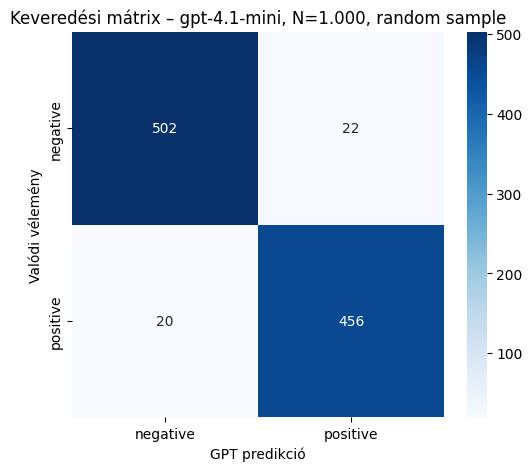

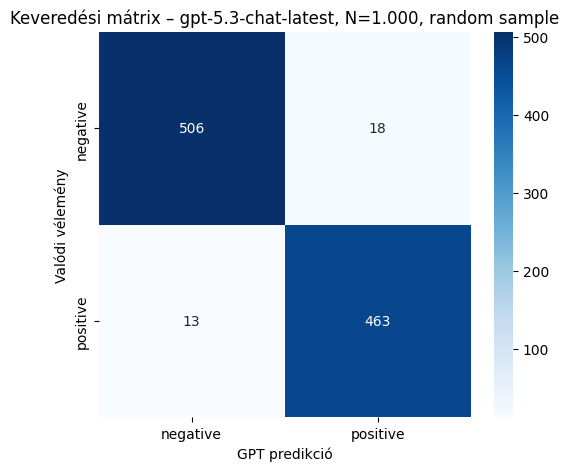

In [ ]:
# ============================================================
# 14. Keveredési mátrix ábrázolása
# ============================================================

for model_name in MODEL_NAMES:
    pred_col = f"gpt_prediction_{model_name.replace('.', '_').replace('-', '_')}"
    eval_df = sample_df.dropna(subset=[pred_col]).copy()

    y_true = eval_df["sentiment"]
    y_pred = eval_df[pred_col]

    cm = confusion_matrix(y_true, y_pred, labels=["negative", "positive"])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["negative", "positive"],
        yticklabels=["negative", "positive"]
    )
    plt.title(f"Keveredési mátrix – {model_name}, N=1.000, random sample")
    plt.xlabel("GPT predikció")
    plt.ylabel("Valódi vélemény")
    plt.show()


## 15. Hibás besorolások listázása

Ez a cella segít a kvalitatív hibaanalízisben.
Megnézheted, mely review-kat sorolta tévesen pozitívnak vagy negatívnak a ChatGPT.

A kétmodell-es változatban külön megjelenítjük a GPT-4.1 mini és a GPT-5.3 Instant
hibás besorolásait, hogy kvalitatív szinten is összehasonlítható legyen a működésük.


In [ ]:
# ============================================================
# 15. Hibás besorolások listázása
# ============================================================

for model_name in MODEL_NAMES:
    pred_col = f"gpt_prediction_{model_name.replace('.', '_').replace('-', '_')}"
    eval_df = sample_df.dropna(subset=[pred_col]).copy()
    errors_df = eval_df[eval_df["sentiment"] != eval_df[pred_col]].copy()

    print("=" * 80)
    print(f"Hibás besorolások – {model_name}")
    print("Hibás besorolások száma:", len(errors_df))
    display(errors_df[["review", "sentiment", pred_col]].head(10))


Hibás besorolások – gpt-4.1-mini
Hibás besorolások száma: 42


,review,sentiment,gpt_prediction_gpt_4_1_mini
20,"The production quality, cast, premise, authent...",positive,negative
21,I've never really been sure whether I liked th...,positive,negative
34,Definitely one of the lesser of the Astaire/Ro...,positive,negative
50,A ruthless assassin has been hired to eliminat...,negative,positive
62,Hammerhead is a combination between the mad sc...,negative,positive
94,"This movie is sort of similar to ""Better Off D...",positive,negative
145,"I liked the quiet noir of the first part, the ...",positive,negative
148,It's telling that as of the entry of this comm...,negative,positive
244,There is a DVD published in the UK in 2002 Cod...,negative,positive
266,"No this is not an Ed Wood movie. ""Angora Love""...",positive,negative


Hibás besorolások – gpt-5.3-chat-latest
Hibás besorolások száma: 31


,review,sentiment,gpt_prediction_gpt_5_3_chat_latest
20,"The production quality, cast, premise, authent...",positive,negative
34,Definitely one of the lesser of the Astaire/Ro...,positive,negative
62,Hammerhead is a combination between the mad sc...,negative,positive
145,"I liked the quiet noir of the first part, the ...",positive,negative
148,It's telling that as of the entry of this comm...,negative,positive
159,... so I thought I'd throw in a few words abou...,negative,positive
169,"A 'Wes Craven presents' movie from 1995, direc...",negative,positive
254,The Thumb idea isn't such a winner the second ...,negative,positive
277,The thing I remember most about this film is t...,positive,negative
313,A young solicitor in sent to a remote area to ...,positive,negative


## 16. Rövid kutatásmódszertani értelmezés

Ez a notebook egy **LLM-alapú sentiment osztályozási pilot** megoldást valósít meg.
A mintaalapú megközelítés előnye, hogy:

- gyorsan kipróbálható ugyanaz az elemzési pipeline több modellen,
- ellenőrizhető, hogy a különböző OpenAI-modellek mennyire stabilan reprodukálják az IMDb-címkéket,
- a kvantitatív mutatók mellett kvalitatív hibaanalízis is végezhető,
- ugyanazon mintán közvetlenül összehasonlítható a **GPT-4.1 mini** és a **GPT-5.3 Instant** teljesítménye.

Ez a megoldás különösen hasznos előkészítő, pilot vagy benchmark-jellegű kutatásokban,
ahol a cél nemcsak az osztályozás, hanem a modellek viselkedésének összevetése is.


In [ ]:
# ============================================================
# 16/A. Megjegyzés a további bővítéshez
# ============================================================

# Innen tovább lehet lépni például:
# - futási idő összehasonlítására,
# - tokenköltség becslésére,
# - modellenkénti részletes hibacsoportok kialakítására,
# - vagy további modellek (pl. újabb OpenAI-modellek) bevonására.

print("A kétmodell-es összehasonlító notebook előkészítése elkészült.")


A kétmodell-es összehasonlító notebook előkészítése elkészült.
